In [1]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt
from scipy.interpolate import griddata
import pandas as pd
import os 


21/03/26 - 21:00:30 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
21/03/26 - 21:00:30 - pyGIMLi - INFO - Cache c:\Users\sider\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 27): C:\Users\sider\AppData\Roaming\pygimli\Cache\17970140561219481632


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x19894225c10>)

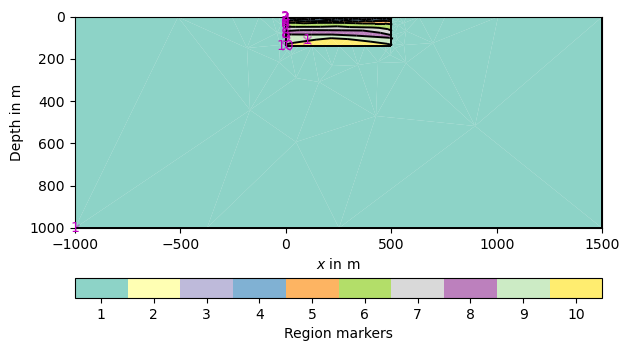

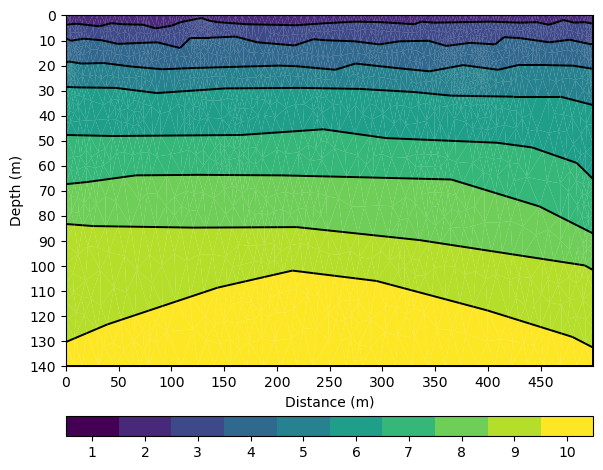

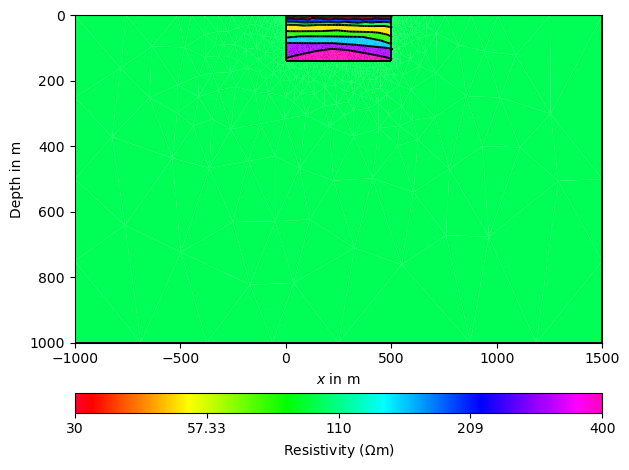

In [2]:
world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)

poly=mt.createRectangle(start=[0, -140], end=[500, 0], marker=1)

interfaces = []

for i in range(9):

    coords = np.loadtxt(f'shape_{i}.txt')
    line = mt.createPolygon(coords, isClosed=False)
    interfaces.append(line)

geom = mt.mergePLC([world] + interfaces + [poly])

geom.addRegionMarker(pos=[0, -1], marker=2)
geom.addRegionMarker(pos=[0, -6], marker=3)
geom.addRegionMarker(pos=[0, -12], marker=4)
geom.addRegionMarker(pos=[0, -23], marker=5)
geom.addRegionMarker(pos=[0, -40], marker=6)
geom.addRegionMarker(pos=[0, -60], marker=7)
geom.addRegionMarker(pos=[0, -80], marker=8)
geom.addRegionMarker(pos=[0, -100], marker=9)
geom.addRegionMarker(pos=[0, -140], marker=10)


pg.show(geom,showMesh=True,quality=34)

mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -140,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 10))
cbar.mappable.set_clim(0.5, 10.5)
cbar.set_ticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

ax.set_xlim(0, 500)
ax.set_ylim(-140, 0)
ax.set_yticks(np.arange(-140, 1, 10)) 
ax.set_xticks(np.arange(0, 500, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")

plt.draw()


spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,100],
        [3,30],
        [4,200],
        [5,100],
        [6,50],
        [7,80],
        [8,150],
        [9,300],
        [10,400]
        ] # resistivity for each region
pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='gist_rainbow',logScale=True,aspect='auto')

21/03/26 - 21:00:32 - pyGIMLi - INFO - Data error estimate (min:max)  0.05000646492989695 : 0.05498040002706264
21/03/26 - 21:00:32 - pyGIMLi - INFO - 0.662636985614011 1229.5566691596337
21/03/26 - 21:00:32 - pyGIMLi - INFO - Simulated data:  Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
21/03/26 - 21:00:32 - pyGIMLi - INFO - The data contains :  ['a', 'b', 'err', 'i', 'ip', 'iperr', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
21/03/26 - 21:00:32 - pyGIMLi - INFO - Sim rhoa (min/max) :  57.690391453248104 140.35602680087445
21/03/26 - 21:00:32 - pyGIMLi - INFO - Selected data noise % (min/ma)x :  5.000646492989695 5.498040002706264
21/03/26 - 21:00:32 - pyGIMLi - INFO - filtered rhoa minmax dd :  57.690391453248104 140.35602680087445


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100


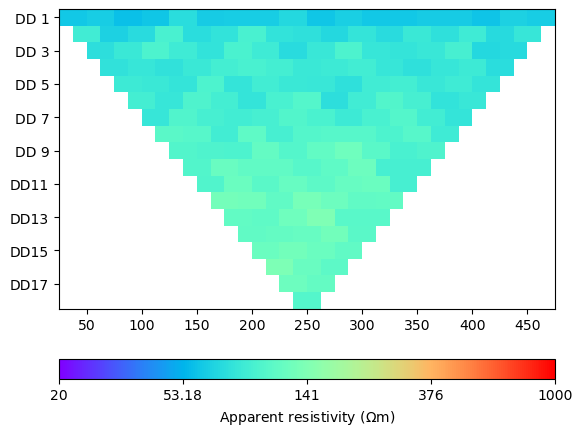

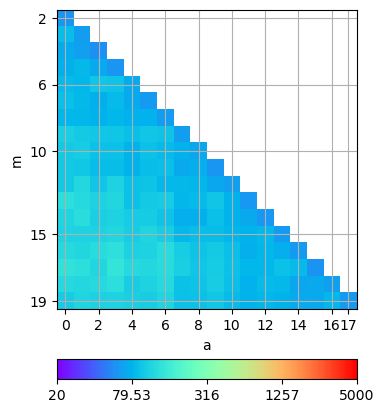

In [3]:
data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=5, noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data['err']),np.linalg.norm(data['rhoa']))
pg.info('Simulated data: ',data)
pg.info('The data contains : ',data.dataMap().keys())
pg.info('Sim rhoa (min/max) : ' ,min(data['rhoa']), max(data['rhoa']))
pg.info('Selected data noise % (min/ma)x : ', min(data['err'])*100, max(data['err'])*100)

data.remove(data['rhoa']<0)
pg.info('filtered rhoa minmax dd : ', min(data['rhoa']), max(data['rhoa']))

output_dir = "new_model"
os.makedirs(output_dir, exist_ok=True) #Make new dir to save files

data.save(os.path.join(output_dir, 'new_dd.dat'))

ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=5000,logScale=True,title='DD')

np.save(os.path.join(output_dir, 'abmn_dd.npy'), np.column_stack([data['a'], data['b'], data['m'], data['n']]))
np.save(os.path.join(output_dir, 'res_all_dd.npy'), np.column_stack([data['rhoa']]))
abmn_data_dd = np.load(os.path.join(output_dir, 'abmn_dd.npy'))
res_data_dd=np.load(os.path.join(output_dir, 'res_all_dd.npy'))

In [4]:
# Function to handle NaN values and get the NaN mask

def fill_nan(image):
    
    nan_mask = np.isnan(image)
    mean_value = np.nanmean(image)
    image[nan_mask] = mean_value

    return image, nan_mask


# Function to reconstruct the image using significant indices and their values

def reconstruct_compressed_image(image_shape, significant_indices, pixel_values):

    # Create an empty image with the given shape
    compressed_image = np.full(image_shape, np.nan)

    # Assign the provided pixel values to the significant indices
    compressed_image[significant_indices] = pixel_values

    # Interpolate to fill in the missing values
    x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
    mask = ~np.isnan(compressed_image)
    try:
        interpolated_image = griddata(
            (x[mask], y[mask]),  # Points with known values
            compressed_image[mask],  # Known values
            (x, y),  # Points to interpolate
            method='linear'  # Interpolation 
            )
    except:
        interpolated_image = griddata(
            (x[mask], y[mask]),  
            compressed_image[mask],  
            (x, y),  
            method='nearest')   #Fallback to nearest if linear fails (e.g., due to insufficient points)
        
    return interpolated_image

def compress_and_reconstruct(image, num_pixels_to_keep, z_factor):
    # Handle NaN values and get the NaN mask
    image, nan_mask = fill_nan(image)

    # IMPRORTANT!! Because I calculate contributions with the whole information of the matrix,
    #  I need to do SVD with the whole matrix, not reduced one.
    U, S, Vt = np.linalg.svd(image, full_matrices=False)

    contributions = np.abs(U) @ np.abs(Vt)

    # Apply depth weighting to contributions
    rows,cols = np.arange(image.shape[0]),np.arange(image.shape[1])
    z=rows/np.max(rows)
    depth_weight=1+z_factor*z   
    depth_weight=depth_weight[:,None]
    contributions*=depth_weight

    contributions[nan_mask] = -np.inf
    #I WILL ALSO REMOVE THE "ANCHORS" BECAUSE I WANT TO SEE THE INCREASE IN ERROR WITHOUT BIASES 
    rows_0=np.where(~nan_mask[:,0])[0] 
    if len(rows_0)>0:
        r_min=rows_0[0]
        r_max=rows_0[-1]
        r_med=rows_0[len(rows_0)//2]
        contributions[r_min,0]=np.inf 
        contributions[r_max,0]=np.inf
        contributions[r_med,0]=np.inf 

    _, valid_cols = np.where(~nan_mask)
    if len(valid_cols) > 0:
        last_col = np.max(valid_cols)
        rows_last = np.where(~nan_mask[:, last_col])[0]
        if len(rows_last) > 0:
            r_last_min = rows_last[0] 
            contributions[r_last_min, last_col] = np.inf

    flat_indices = np.argsort(contributions.flatten())[::-1][:num_pixels_to_keep]
    significant_indices = np.unravel_index(flat_indices, image.shape)

    # Restore NaN values 
    compressed_image = np.dot(U, np.dot(np.diag(S), Vt))
    compressed_image[nan_mask] = np.nan
 
    return compressed_image, significant_indices, nan_mask, contributions


#Function to plot ERT measurements as a checkerboard heatmap

def plot_ert_checkerboard(data,plot=0):

    """
    Plots ERT measurements as a checkerboard heatmap.
    Parameters:
    data (pd.DataFrame): A DataFrame containing columns 'A', 'B', 'M', 'N', and 'Res'.
    """

    #Extract unique electrode positions
    electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
    electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}

    #Create a grid
    grid_size = len(electrode_map)
    heatmap = np.full((grid_size, grid_size), np.nan)

    #Map values to the grid
    for _, row in data.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        heatmap[y, x] = row['Res']


    if plot==1:

        #Plot the checkerboard heatmap
        plt.imshow(np.log10(heatmap), cmap='gist_rainbow', interpolation='nearest')
        plt.colorbar(label='ERT Measurement Value')
        plt.xticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()), rotation=90)
        plt.yticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()))
        plt.xlabel('Electrode A')
        plt.ylabel('Electrode N')
        plt.title('ERT Checkerboard Heatmap')

        
    return heatmap


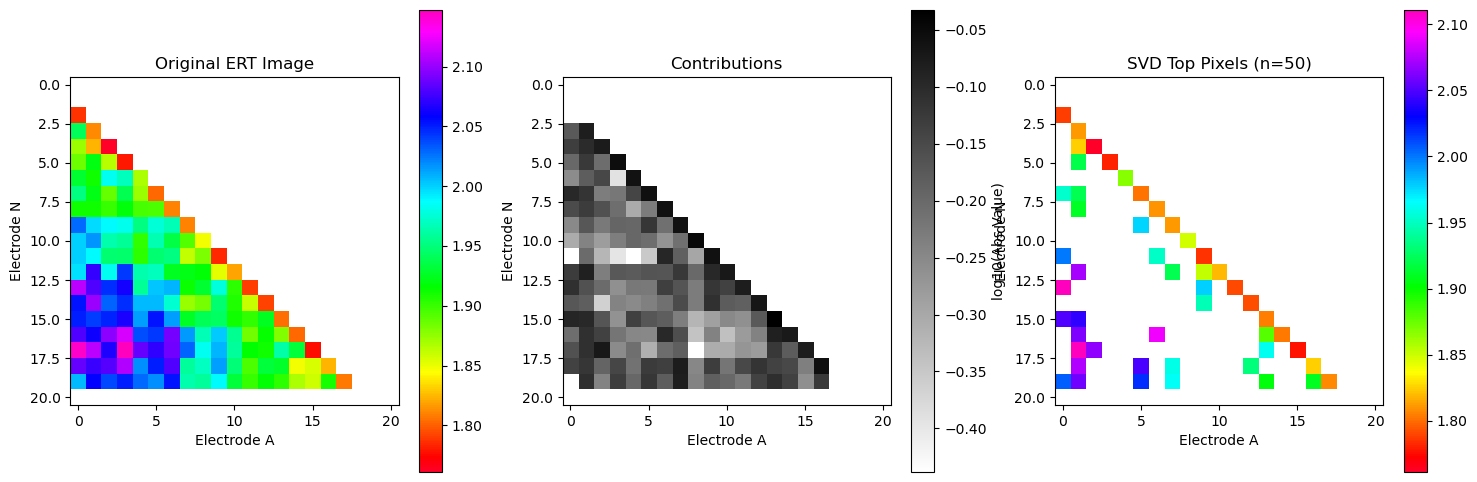

In [5]:
abmn=np.load(os.path.join(output_dir, 'abmn_dd.npy'))
res_all=np.load(os.path.join(output_dir, 'res_all_dd.npy'))
data_all=np.column_stack([abmn,res_all[:,0]])
data=pd.DataFrame(data_all,columns=['A','B','M','N','Res'])
image=plot_ert_checkerboard(data,plot=0) 
num_singular_values = 50

#compress and reconstruct the image using SVD
compressed_image, significant_indices,nan_mask,contributions_toplot=compress_and_reconstruct(image, num_singular_values,z_factor=0)
image[nan_mask] = np.nan


#get pixel values at significant indices
pixel_values = compressed_image[significant_indices]
real_values = image[significant_indices]

#reconstruct the compressed image using significant indices and their values
reconstructed_compressed_image = reconstruct_compressed_image(image.shape, significant_indices, real_values)
predicted_values=reconstructed_compressed_image[significant_indices]
to_plot_image = np.full(image.shape, np.nan)
to_plot_image[significant_indices] = predicted_values 

#contributions of each pixel to validate the reconstruction 
contributions_toplot[nan_mask] = np.nan  


fig, axes = plt.subplots(1, 3, figsize=(18, 6))



im1 = axes[0].imshow(np.log10(image), cmap='gist_rainbow')
axes[0].set_title('Original ERT Image')
axes[0].set_xlabel('Electrode A')
axes[0].set_ylabel('Electrode N')
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(np.log10(contributions_toplot), cmap='binary')
axes[1].set_title('Contributions')
axes[1].set_xlabel('Electrode A')
axes[1].set_ylabel('Electrode N')
fig.colorbar(im2, ax=axes[1], label='log10(Abs Value)')

im3 = axes[2].imshow(np.log10(to_plot_image), cmap='gist_rainbow')
axes[2].set_title(f'SVD Top Pixels (n={num_singular_values})')
axes[2].set_xlabel('Electrode A')
axes[2].set_ylabel('Electrode N')
fig.colorbar(im3, ax=axes[2])

plt.show()

21/03/26 - 21:00:32 - pyGIMLi - INFO - Found 2 regions.
21/03/26 - 21:00:32 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
21/03/26 - 21:00:32 - pyGIMLi - INFO - Found 2 regions.
21/03/26 - 21:00:32 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
21/03/26 - 21:00:32 - pyGIMLi - INFO - Creating forward mesh from region infos.
21/03/26 - 21:00:32 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
21/03/26 - 21:00:32 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1022 Cells: 1900 Boundaries: 1496
21/03/26 - 21:00:32 - pyGIMLi - INFO - Use median(data values)=90.3603732272228


Initial Inversion chi2: 1.14


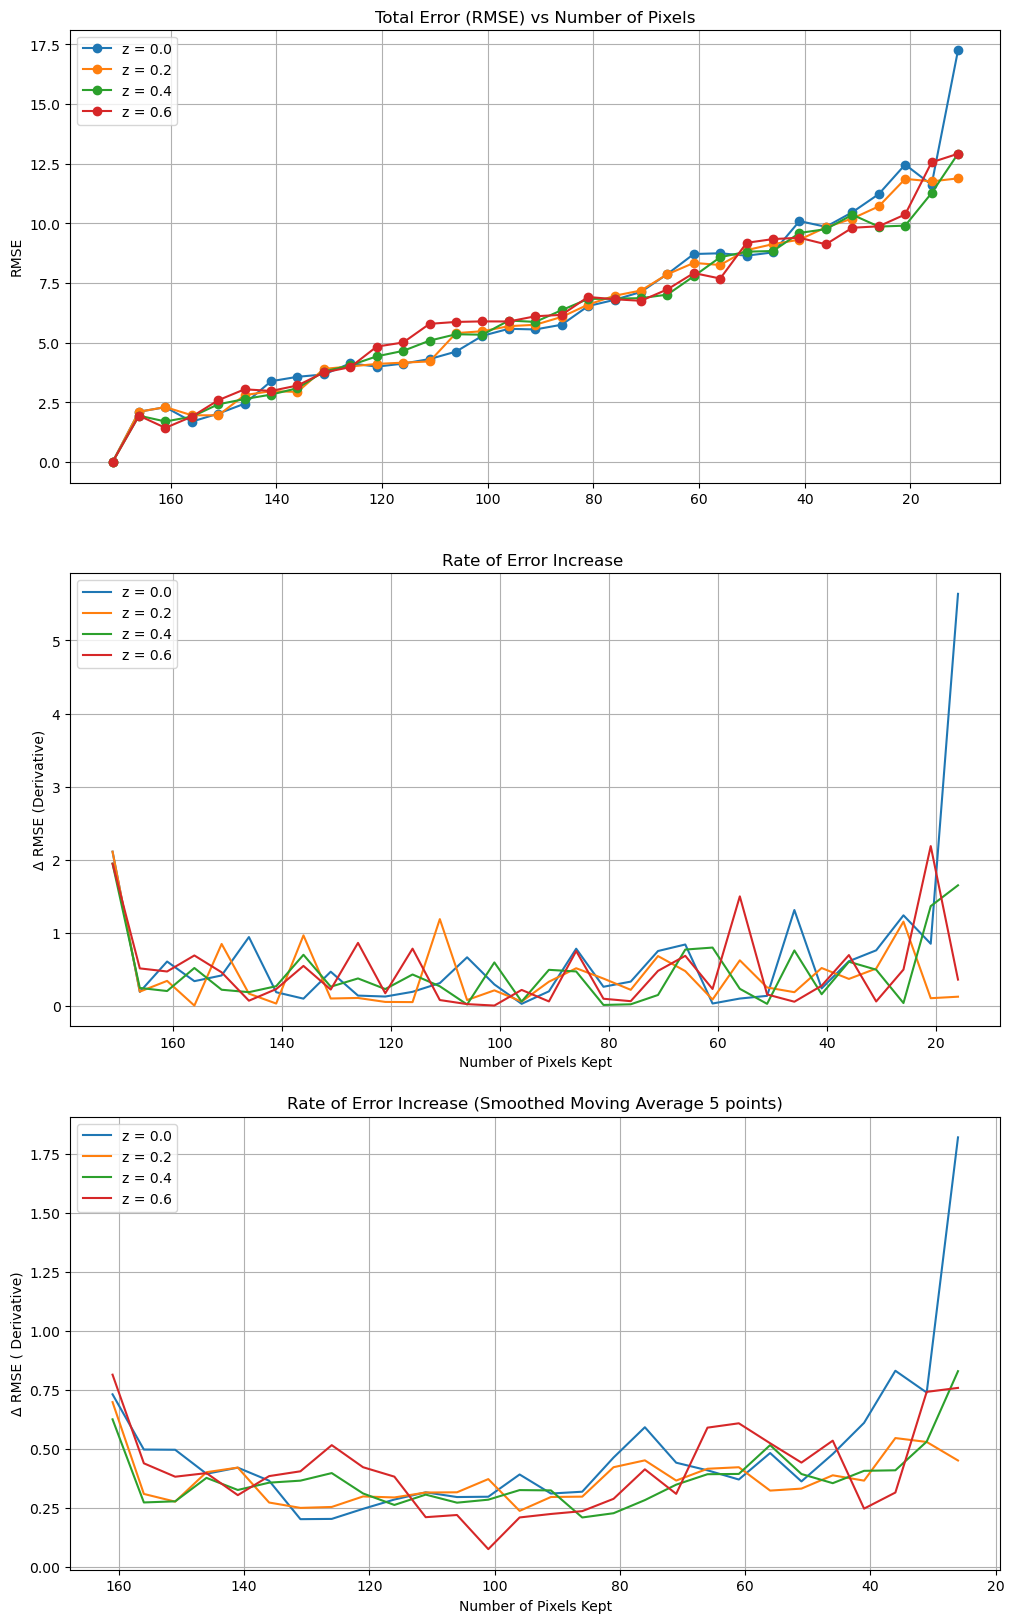

In [6]:
pg_data = pg.DataContainerERT(os.path.join(output_dir, 'new_dd.dat')) 

mgr1 = ert.ERTManager(pg_data)
inv1 = mgr1.invert(lam=20, verbose=False)
chi2_1 = mgr1.inv.chi2()
print(f"Initial Inversion chi2: {chi2_1:.2f}")

valid_mask = ~np.isnan(image)
original_valid_pixels = image[valid_mask]

min_rmse = float('inf')
best_pixels_count = 0
best_reconstructed_image = None

pixel_range = range(original_valid_pixels.size, 9, -5) #num of valid pixels!

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 20))

z_values = np.arange(0, 0.8, 0.2)
for z in z_values:
    rmse_list = [] 
    
    for num_pixels in pixel_range:
        #compress
        compressed_image, significant_indices, nan_mask_loop,_ = compress_and_reconstruct(image.copy(), num_pixels, z_factor=z)
        real_values = image[significant_indices]
        #reconstruct
        reconstructed_img = reconstruct_compressed_image(image.shape, significant_indices, real_values)
        #rmse for valid pixels only
        recon_valid_pixels = reconstructed_img[valid_mask]
        rmse = np.sqrt(np.mean((original_valid_pixels - recon_valid_pixels)**2))
    
        rmse_list.append(rmse)
    rmse_diff=np.abs(np.diff(rmse_list))

    #smoothing moving average 5 points
    if len(rmse_diff) >= 5:
        smooth_diff = (rmse_diff[:-4] + rmse_diff[1:-3] + rmse_diff[2:-2] + rmse_diff[3:-1] + rmse_diff[4:]) / 5
        
        #remove 2points from start and 3 from the end 
        plot_x = list(pixel_range)[2:-3]
        
        ax3.plot(plot_x, smooth_diff, label=f'z = {z:.1f}', linestyle='-' )

    #rmse plot
    ax1.plot(list(pixel_range), rmse_list, label=f'z = {z:.1f}', linestyle='-', marker='o')
    #no smoothing
    ax2.plot(list(pixel_range[:-1]), rmse_diff, label=f'z = {z:.1f}', linestyle='-' )

    

#plots
ax1.invert_xaxis()
ax1.set_ylabel('RMSE')
ax1.set_title('Total Error (RMSE) vs Number of Pixels')
ax1.grid(True)
ax1.legend(loc='upper left')


ax2.invert_xaxis()
ax2.set_ylabel('Δ RMSE (Derivative)')
ax2.set_xlabel('Number of Pixels Kept')
ax2.set_title('Rate of Error Increase ')
ax2.grid(True)
ax2.legend(loc='upper left')

ax3.invert_xaxis()
ax3.set_ylabel('Δ RMSE ( Derivative)')
ax3.set_xlabel('Number of Pixels Kept')
ax3.set_title('Rate of Error Increase (Smoothed Moving Average 5 points)')
ax3.grid(True)
ax3.legend(loc='upper left')


plt.show()

